## Section 0: Simulasi app -- 5 foto masuk, 6 hasil DHC keluar

Reuse SEMUA model yang sudah dilatih (nggak ada training di notebook ini):
- Segmentasi lateral (`04_yolo_seg_lateral_pilot.ipynb`)
- Segmentasi frontal (`09_yolo_seg_frontal_pilot.ipynb`)
- Segmentasi oklusal (`12_yolo_seg_occlusal_pilot.ipynb`)
- Detector kaninus+distal_most (`08_canine_distal_detector.ipynb`)
- Rumus overjet/overbite/Angle (`05_overjet_angle_from_mask.ipynb`)
- Rumus Missing/Displacement dari frontal (`10_frontal_missing_displacement.ipynb`)
- Rumus Crossbite posterior dari frontal, tepi bukal (`13_fdi_number_detector.ipynb` Section 16)
- Rumus Missing (Arch Occupancy) & Crowding (Little's Index) dari oklusal (`14_occlusal_missing_crowding.ipynb` Section 9 & 14)

**5 foto per pasien**: frontal, lateral kanan, lateral kiri, oklusal atas, oklusal bawah. Semua sudah diproses -- Overjet/Overbite/Angle (lateral), Missing/Displacement/Crossbite posterior (frontal), Missing/Crowding (oklusal).

**Overjet/Overbite/Angle**: dihitung dari lateral kanan DAN kiri, laporan akhir ambil yang **terburuk** (severity = seberapa jauh dari rentang normal) -- bukan pilih salah satu secara acak.

**Ganti pasien**: tinggal ganti `PATIENT_ID` di Section 2 (folder yang tersedia: `2021.69`, `2021.111`, `2023.14`, `2018.56`, `2021.04`, di `Dataset/app_simulation_patient/`).

**PENTING -- foto oklusal**: kode file (`4`/`5`) TIDAK konsisten sbg bawah/atas per pasien (lihat catatan `REVERSED_OKLUSAL_PATIENTS` di Section 2) -- pasien baru di luar daftar itu WAJIB dicek manual dulu sebelum dipercaya hasil oklusalnya.

## Section 1: Setup -- load semua model

In [20]:
from pathlib import Path

import numpy as np
import cv2
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO
from sklearn.cluster import KMeans

import io
from IPython.display import display, Image as IPImage

ROOT = Path(".")
SIM_ROOT = Path("/Users/benediktaaa/Documents/AML/dental-malocclusion/Dataset/app_simulation_patient")

lateral_seg_model = YOLO(str(ROOT / "runs/segment/lateral_pilot_runs/baseline_seg-3/weights/best.pt"))
frontal_seg_model = YOLO(str(ROOT / "runs/segment/frontal_pilot_runs/baseline_seg/weights/best.pt"))
occlusal_seg_model = YOLO(str(ROOT / "runs/segment/occlusal_pilot_runs/baseline_seg/weights/best.pt"))
det_model = YOLO(str(ROOT / "runs/detect/canine_distal_runs/v3-2/weights/best.pt"))
# v3-2 (154 foto, 50 epoch) -- mAP50=0.913 di test-set, naik dari v2 (108 foto, 30 epoch).
# Kaninus khususnya membaik jauh (AP50 0.842) -- lihat `08_canine_distal_detector.ipynb` Section 5.

SEG_CONF, SEG_IOU = 0.5, 0.4
DET_CONF_CANINE, DET_CONF_DISTAL, DET_IOU = 0.25, 0.25, 0.5
ANGLE_THRESHOLD = 0.25
OVERJET_LOW, OVERJET_HIGH = 0.0, 0.5
OVERBITE_LOW, OVERBITE_HIGH = 0.0, 0.5
GAP_RATIO_THRESHOLD = 0.5
DISPLACEMENT_THRESHOLD = 0.35

# --- guard kualitas hasil lateral (ditambahkan setelah audit 44 foto, lihat Section 3) ---
EDGE_SLIVER_MAX_AREA_RATIO = 0.30   # mask nempel-tepi & lebih kecil dari ini = noise, dibuang
INCISOR_MIN_AREA_RATIO = 0.5        # mask insisivus di bawah ini = mencurigakan, hasil ditandai
OVERJET_PLAUSIBLE = 2.0             # |overjet| di atas ini mustahil secara klinis
OVERBITE_PLAUSIBLE = 1.5            # |overbite| di atas ini mustahil secara klinis

# konstanta Missing (Arch Occupancy) & Crowding (Little's Irregularity Index) dari
# oklusal -- reuse persis dari `14_occlusal_missing_crowding.ipynb` Section 9 & 14,
# statusnya sama: kalibrasi kasar dari sample kecil, bukan angka klinis baku.
MISSING_ARC_GAP_THRESHOLD = 0.6
ROBUST_RESIDUAL_FACTOR = 2.5
LITTLES_ANTERIOR_N = 3
LITTLES_THRESHOLD_SUM = 1.05
LITTLES_STEP_THRESHOLD = 0.30

CROSSBITE_THRESHOLD = 0.05
# reuse persis dari `13_fdi_number_detector.ipynb` Section 16 (tepi bukal, REKOMENDASI) --
# ~30% lebar gigi, divalidasi ke 6 pasien + 3 foto luar (termasuk 1 kasus posterior
# crossbite klinis confirmed, ke-flag TEPAT di posisi premolar-molar kedua sisi).

print("semua model dimuat.")

semua model dimuat.


## Section 2: Pilih pasien

Ganti `PATIENT_ID` buat coba pasien lain (semua folder tersedia sudah dicek: 5 foto lengkap, tanpa kawat/braces).

In [21]:
PATIENT_ID = "2018.08"  # pilihan lain: "2021.69", "2021.111", "2023.14", "2018.56", "2021.04",
# "2019.20", "2023.25", "2020.35", "2021.86", "2019.25"

FLAGGED_PATIENTS = {"2018.08", "2018.73", "2018.57a", "2021.108", "2022.24", "2022.74", "2023.33", "2023.55"}
# flag pribadi (belum dicek/dikonfirmasi) -- pasien yg dicurigai ADA MASALAH (bisa
# kode foto oklusal ketuker kayak REVERSED_OKLUSAL_PATIENTS di bawah, bisa juga
# masalah lain, msh perlu dicek manual satu-satu). Dipisah dari REVERSED_OKLUSAL_PATIENTS
# krn itu udah CONFIRMED lewat cek visual, ini belum.

REVERSED_OKLUSAL_PATIENTS = {"2021.04", "2023.14", "2018.08", "2018.73", "2018.57a"}
# BUG DATA (lihat `14_occlusal_missing_crowding.ipynb` Section 6): kode file foto
# oklusal ("...4.JPG"/"...5.JPG") TIDAK konsisten sbg bawah/atas per pasien -- dicek
# manual (visual, rugae palatum vs lidah) ke semua pasien yg pernah dites, 5 pasien
# di atas kodenya kebalik. Kalau nambah pasien baru di luar daftar ini, cek manual
# dulu foto kode 4 vs 5 -- rugae/langit-langit tanpa lidah = atas, ada lidah = bawah.


def get_patient_photos(patient_id):
    folder = SIM_ROOT / patient_id
    photos = {}
    for p in folder.glob("*.JPG"):
        code_ = p.stem[-1]
        photos[code_] = p
    if patient_id in REVERSED_OKLUSAL_PATIENTS:
        oklusal_bawah, oklusal_atas = photos.get("5"), photos.get("4")
    else:
        oklusal_bawah, oklusal_atas = photos.get("4"), photos.get("5")
    return {
        "frontal": photos.get("1"),
        "lateral_kanan": photos.get("2"),
        "lateral_kiri": photos.get("3"),
        "oklusal_bawah": oklusal_bawah,
        "oklusal_atas": oklusal_atas,
    }


if PATIENT_ID in FLAGGED_PATIENTS and PATIENT_ID not in REVERSED_OKLUSAL_PATIENTS:
    print(f"PERINGATAN: {PATIENT_ID} ada di FLAGGED_PATIENTS tapi belum dicek/dikonfirmasi -- cek manual dulu (rugae vs lidah) sebelum percaya hasil oklusal atas/bawahnya.")

photos = get_patient_photos(PATIENT_ID)
for k, v in photos.items():
    print(f"{k:15s}: {v.name if v else '(kosong)'}")

frontal        : 201808201807191.JPG
lateral_kanan  : 201808201807192.JPG
lateral_kiri   : 201808201807193.JPG
oklusal_bawah  : 201808201807195.JPG
oklusal_atas   : 201808201807194.JPG


## Section 3: Helper -- segmentasi, split lengkung, anchor kaninus+distal_most

Reuse persis dari `07_lateral-unseen-test.ipynb` (lateral) & `10_frontal_missing_displacement.ipynb` (frontal), termasuk fix split atas-bawah (fit kurva kuadratik, bukan kmeans posisi-y mentah).

In [22]:
def instance_features_from_mask(pts):
    x0, y0 = pts.min(axis=0)
    x1, y1 = pts.max(axis=0)
    # oriented_width (dari cv2.minAreaRect) ditambahin buat dipakai Little's Index
    # (Section 6 oklusal) -- robust ke rotasi, beda dari width/height bbox lurus.
    (rcx, rcy), (rw, rh), angle = cv2.minAreaRect(pts.astype(np.float32))
    return {"points": pts, "centroid": [float((x0 + x1) / 2), float((y0 + y1) / 2)], "bbox": (x0, y0, x1, y1),
            "width": x1 - x0, "height": y1 - y0, "oriented_width": float(max(rw, rh))}


def filter_spurious_instances(feats, min_area_ratio=0.15):
    def area(f):
        x0, y0, x1, y1 = f["bbox"]
        return (x1 - x0) * (y1 - y0)
    areas = [area(f) for f in feats]
    median_area = np.median(areas)
    return [f for f, a in zip(feats, areas) if a >= median_area * min_area_ratio]


def drop_edge_slivers(feats, img_w, img_h, edge_tol=3, max_area_ratio=EDGE_SLIVER_MAX_AREA_RATIO):
    """Buang mask yang NEMPEL tepi frame DAN jauh lebih kecil dari gigi lain.
    Kombinasi dua syarat itu penting -- kalau cuma pakai "nempel tepi", gigi asli
    paling depan yang kepotong frame ikut kebuang.

    Ditemukan dari audit 44 foto lateral: `2018.05` lateral kanan punya mask palsu di
    LUAR mulut (tepi kanan frame, area cuma 0.20x median, 13x20px) yang lolos
    `filter_spurious_instances` (ambangnya 0.15) lalu kepilih jadi anchor "insisivus
    sentral atas" -> overjet jadi 9.33 (mustahil).

    Ambang 0.30 dikalibrasi dari data itu: noise 2018.05 = 0.20x (kebuang), sedangkan
    gigi ASLI yang kepotong frame di `2021.86` = 0.45x & 0.52x (tetap aman). Diuji ulang
    ke semua 44 foto lateral: 0 regresi, 36 nilai overjet identik, cuma kasus 2018.05
    yang berubah (dari 9.33 jadi "tidak bisa dihitung" -- lebih jujur drpd angka palsu).

    Cuma dipakai di `analyze_lateral`; frontal/oklusal belum diuji jadi belum dipasangin."""
    if not feats:
        return feats
    areas = [(f["bbox"][2] - f["bbox"][0]) * (f["bbox"][3] - f["bbox"][1]) for f in feats]
    med = float(np.median(areas))
    out = []
    for f, a in zip(feats, areas):
        x0, y0, x1, y1 = f["bbox"]
        touches_edge = (x0 <= edge_tol or y0 <= edge_tol or x1 >= img_w - edge_tol or y1 >= img_h - edge_tol)
        if touches_edge and a < med * max_area_ratio:
            continue
        out.append(f)
    return out


def split_arch_kmeans(feats):
    """Fit kurva kuadratik ke semua gigi dulu (jadi semacam garis tengah atas-bawah),
    baru cluster RESIDUAL-nya -- bukan posisi-y mentah (lebih robust, lihat catatan
    di 10_frontal_missing_displacement.ipynb)."""
    if len(feats) < 4:
        if len(feats) < 2:
            return list(feats), []
        ys = np.array([[f["centroid"][1]] for f in feats])
        km = KMeans(n_clusters=2, n_init=10, random_state=0).fit(ys)
        upper_label = int(np.argmin(km.cluster_centers_.flatten()))
        upper = [f for f, l in zip(feats, km.labels_) if l == upper_label]
        lower = [f for f, l in zip(feats, km.labels_) if l != upper_label]
        return upper, lower
    xs = np.array([f["centroid"][0] for f in feats])
    ys = np.array([f["centroid"][1] for f in feats])
    coeffs = np.polyfit(xs, ys, deg=2)
    residuals = ys - np.polyval(coeffs, xs)
    km = KMeans(n_clusters=2, n_init=10, random_state=0).fit(residuals.reshape(-1, 1))
    upper_label = int(np.argmin(km.cluster_centers_.flatten()))
    upper = [f for f, l in zip(feats, km.labels_) if l == upper_label]
    lower = [f for f, l in zip(feats, km.labels_) if l != upper_label]
    return upper, lower


def dedupe_top1_per_arch_boxes(boxes):
    if not boxes:
        return []
    if len(boxes) < 2:
        arch = [0]
    else:
        ys = np.array([[b["cy"]] for b in boxes])
        km = KMeans(n_clusters=2, n_init=10, random_state=0).fit(ys)
        upper_label = int(np.argmin(km.cluster_centers_.flatten()))
        arch = [0 if l == upper_label else 1 for l in km.labels_]
    for b, a in zip(boxes, arch):
        b["arch"] = a
    best = {}
    for b in boxes:
        key = (b["cls"], b["arch"])
        if key not in best or b["conf"] > best[key]["conf"]:
            best[key] = b
    return list(best.values())


def resolve_canine_anchor(arch, anchors, arch_feats_map):
    other = "lower" if arch == "upper" else "upper"
    canine_f = anchors[arch]["canine"]
    if canine_f is not None:
        return canine_f, "direct"
    other_canine_f = anchors[other]["canine"]
    arch_feats = arch_feats_map[arch]
    if other_canine_f is None or not arch_feats:
        return None, "none"
    ref_x = other_canine_f["centroid"][0]
    inferred = min(arch_feats, key=lambda f: abs(f["centroid"][0] - ref_x))
    return inferred, "cross"


def resolve_distal_anchor(arch, anchors, arch_feats_map, canine_f, direction):
    distal_f = anchors[arch]["distal_most"]
    if distal_f is not None:
        return distal_f, "direct"
    af = arch_feats_map[arch]
    if not af or direction is None or canine_f is None:
        return None, "none"
    candidates = [f for f in af if f is not canine_f]
    if not candidates:
        return None, "none"
    fallback = max(candidates, key=lambda f: f["centroid"][0] * direction)
    return fallback, "seg_fallback"


def determine_photo_direction(anchors):
    for arch in ("upper", "lower"):
        c = anchors[arch]["canine"]
        d = anchors[arch]["distal_most"]
        if c is not None and d is not None:
            return 1 if d["centroid"][0] > c["centroid"][0] else -1
    return None


def number_by_anchors(arch_feats, canine_f, distal_f):
    sign = 1 if distal_f["centroid"][0] > canine_f["centroid"][0] else -1
    ordered = sorted(arch_feats, key=lambda f: f["centroid"][0] * sign)
    canine_idx = next(i for i, f in enumerate(ordered) if f is canine_f)
    result = []
    for i, f in enumerate(ordered):
        pos = 3 + (i - canine_idx)
        result.append((f, pos if 1 <= pos <= 8 else None))
    return result

## Section 4: Overjet, Overbite, Angle (dari mask lateral)

Reuse rumus dari `05_overjet_angle_from_mask.ipynb` Section 8-9 (sudah termasuk fix tanda & pemisahan syarat insisivus/molar).

In [23]:
def get_incisors_fdi(upper_result, lower_result):
    def find_pos(result, pos):
        for f, p in result:
            if p == pos:
                return f
        return None
    ui, li = find_pos(upper_result, 1), find_pos(lower_result, 1)
    if ui is None or li is None:
        return None
    return {"upper_incisor": ui, "lower_incisor": li}


def get_molars_fdi(upper_result, lower_result):
    def find_pos(result, pos):
        for f, p in result:
            if p == pos:
                return f
        return None
    um, lm = find_pos(upper_result, 6), find_pos(lower_result, 6)
    if um is None or lm is None:
        return None
    return {"upper_molar": um, "lower_molar": lm}


def get_canines_fdi(upper_result, lower_result):
    def find_pos(result, pos):
        for f, p in result:
            if p == pos:
                return f
        return None
    uc, lc = find_pos(upper_result, 3), find_pos(lower_result, 3)
    if uc is None or lc is None:
        return None
    return {"upper_canine": uc, "lower_canine": lc}


def mesial_direction_from_fdi(upper_result):
    pos_map = {p: f for f, p in upper_result if p is not None}
    if 1 not in pos_map:
        return 1
    max_pos = max(pos_map)
    return 1 if pos_map[1]["centroid"][0] <= pos_map[max_pos]["centroid"][0] else -1


def compute_overjet_proxy(incisors, direction):
    # FIX: sebelumnya pakai centroid, bias kalau lebar insisivus atas/bawah beda dan
    # nggak konsisten sama compute_relationship_proxy (dipakai molar & kaninus). Sekarang pakai tepi
    # mesial (tepi labial insisivus), logika identik sama molar.
    upper_incisor = incisors["upper_incisor"]
    lower_incisor = incisors["lower_incisor"]
    upper_x = upper_incisor["bbox"][0] if direction == 1 else upper_incisor["bbox"][2]
    lower_x = lower_incisor["bbox"][0] if direction == 1 else lower_incisor["bbox"][2]
    dx = (lower_x - upper_x) * direction
    return dx / upper_incisor["width"]


def compute_overbite_proxy(incisors):
    upper_incisor = incisors["upper_incisor"]
    lower_incisor = incisors["lower_incisor"]
    dy = upper_incisor["bbox"][3] - lower_incisor["bbox"][1]
    return dy / upper_incisor["height"]


def compute_relationship_proxy(pair, direction, upper_key, lower_key):
    """Generic -- dipakai buat molar (posisi 6) ATAUPUN kaninus (posisi 3), sesuai
    Section 10 `05_overjet_angle_from_mask.ipynb` (Angle class dicek dari relasi
    bukal/molar DAN kaninus, bukan molar doang)."""
    upper_t, lower_t = pair[upper_key], pair[lower_key]
    upper_mesial_x = upper_t["bbox"][0] if direction == 1 else upper_t["bbox"][2]
    lower_mesial_x = lower_t["bbox"][0] if direction == 1 else lower_t["bbox"][2]
    dx = (lower_mesial_x - upper_mesial_x) * direction
    ratio = dx / upper_t["width"]
    if ratio > ANGLE_THRESHOLD:
        label = "mirip Class II"
    elif ratio < -ANGLE_THRESHOLD:
        label = "mirip Class III"
    else:
        label = "mirip Class I"
    return ratio, label


def overjet_label(proxy):
    if proxy < OVERJET_LOW:
        return "kemungkinan crossbite anterior"
    elif proxy > OVERJET_HIGH:
        return "kemungkinan overjet berlebih"
    return "kemungkinan overjet normal"


def overbite_label(proxy):
    if proxy < OVERBITE_LOW:
        return "kemungkinan open bite"
    elif proxy > OVERBITE_HIGH:
        return "kemungkinan deep bite"
    return "kemungkinan overbite normal"


def analyze_lateral(img_path):
    image = Image.open(img_path)
    seg_pred = lateral_seg_model.predict(source=str(img_path), conf=SEG_CONF, iou=SEG_IOU, verbose=False)[0]
    feats = [] if seg_pred.masks is None else [instance_features_from_mask(xy) for xy in seg_pred.masks.xy]
    feats = filter_spurious_instances(feats)
    feats = drop_edge_slivers(feats, image.width, image.height)  # guard mask palsu di tepi frame
    upper, lower = split_arch_kmeans(feats)
    arch_feats_map = {"upper": upper, "lower": lower}

    det_pred = det_model.predict(source=str(img_path), conf=min(DET_CONF_CANINE, DET_CONF_DISTAL), iou=DET_IOU, verbose=False)[0]
    raw_boxes = []
    if det_pred.boxes is not None:
        for box in det_pred.boxes:
            cls = int(box.cls.item())
            conf = float(box.conf.item())
            thresh = DET_CONF_CANINE if cls == 0 else DET_CONF_DISTAL
            if conf < thresh:
                continue
            x0, y0, x1, y1 = box.xyxy[0].tolist()
            raw_boxes.append({"cls": cls, "conf": conf, "cx": (x0 + x1) / 2, "cy": (y0 + y1) / 2})
    deduped = dedupe_top1_per_arch_boxes(raw_boxes)

    anchors = {"upper": {"canine": None, "distal_most": None}, "lower": {"canine": None, "distal_most": None}}
    for db in deduped:
        cat = "canine" if db["cls"] == 0 else "distal_most"
        best_f, best_arch, best_d = None, None, 1e18
        for arch, fl in arch_feats_map.items():
            for f in fl:
                d = abs(f["centroid"][0] - db["cx"]) + abs(f["centroid"][1] - db["cy"])
                if d < best_d:
                    best_d, best_f, best_arch = d, f, arch
        if best_f is not None:
            anchors[best_arch][cat] = best_f

    direction = determine_photo_direction(anchors)
    arch_results = {}
    for arch in ("upper", "lower"):
        canine_f, _ = resolve_canine_anchor(arch, anchors, arch_feats_map)
        distal_f, _ = resolve_distal_anchor(arch, anchors, arch_feats_map, canine_f, direction)
        af = arch_feats_map[arch]
        if canine_f is not None and distal_f is not None:
            arch_results[arch] = number_by_anchors(af, canine_f, distal_f)
        else:
            arch_results[arch] = [(f, None) for f in af]

    result = {"image": image, "upper_result": arch_results["upper"], "lower_result": arch_results["lower"]}

    incisors = get_incisors_fdi(arch_results["upper"], arch_results["lower"])
    direction2 = mesial_direction_from_fdi(arch_results["upper"])
    result["warnings"] = []
    if incisors is not None:
        result["overjet_proxy"] = compute_overjet_proxy(incisors, direction2)
        result["overjet_label"] = overjet_label(result["overjet_proxy"])
        result["overbite_proxy"] = compute_overbite_proxy(incisors)
        result["overbite_label"] = overbite_label(result["overbite_proxy"])
        result["incisors"] = incisors

        # --- guard kualitas: tandai hasil yang kemungkinan besar salah anchor ---
        # (1) mask insisivus yang dipakai jauh lebih kecil dari gigi lain = kemungkinan
        #     yang kepilih itu serpihan/noise, bukan insisivus asli.
        # (2) angka overjet/overbite di luar rentang yang mungkin secara klinis.
        # Hasilnya TETAP dihitung & ditampilkan, tapi dikasih peringatan -- jangan
        # dipakai buat kesimpulan tanpa ditinjau manual dulu.
        all_feats = [f for f, _ in arch_results["upper"]] + [f for f, _ in arch_results["lower"]]
        areas = [(f["bbox"][2] - f["bbox"][0]) * (f["bbox"][3] - f["bbox"][1]) for f in all_feats]
        med_area = float(np.median(areas)) if areas else 0.0

        def _area_ratio(f):
            a = (f["bbox"][2] - f["bbox"][0]) * (f["bbox"][3] - f["bbox"][1])
            return a / med_area if med_area else 1.0

        if _area_ratio(incisors["upper_incisor"]) < INCISOR_MIN_AREA_RATIO:
            result["warnings"].append("mask insisivus ATAS mungil (kemungkinan salah anchor)")
        if _area_ratio(incisors["lower_incisor"]) < INCISOR_MIN_AREA_RATIO:
            result["warnings"].append("mask insisivus BAWAH mungil (kemungkinan salah anchor)")
        if abs(result["overjet_proxy"]) > OVERJET_PLAUSIBLE:
            result["warnings"].append(f"overjet={result['overjet_proxy']:.2f} di luar rentang masuk akal")
        if abs(result["overbite_proxy"]) > OVERBITE_PLAUSIBLE:
            result["warnings"].append(f"overbite={result['overbite_proxy']:.2f} di luar rentang masuk akal")
    result["reliable"] = (incisors is not None) and not result["warnings"]

    molars = get_molars_fdi(arch_results["upper"], arch_results["lower"])
    if molars is not None:
        result["molar_ratio"], result["molar_label"] = compute_relationship_proxy(molars, direction2, "upper_molar", "lower_molar")
        result["molars"] = molars

    canines = get_canines_fdi(arch_results["upper"], arch_results["lower"])
    if canines is not None:
        result["canine_ratio"], result["canine_label"] = compute_relationship_proxy(canines, direction2, "upper_canine", "lower_canine")
        result["canines"] = canines

    return result

## Section 5: Missing & Displacement (dari mask frontal)

Reuse rumus dari `10_frontal_missing_displacement.ipynb`.

In [24]:
def detect_missing_gaps(arch_feats):
    ordered = sorted(arch_feats, key=lambda f: f["centroid"][0])
    flagged = []
    for a, b in zip(ordered, ordered[1:]):
        gap = b["bbox"][0] - a["bbox"][2]
        avg_width = (a["width"] + b["width"]) / 2
        gap_ratio = gap / avg_width
        if gap_ratio > GAP_RATIO_THRESHOLD:
            flagged.append((a, b, gap_ratio))
    return flagged


def detect_displacement(arch_feats):
    if len(arch_feats) < 4:
        return []
    xs = np.array([f["centroid"][0] for f in arch_feats])
    ys = np.array([f["centroid"][1] for f in arch_feats])
    coeffs = np.polyfit(xs, ys, deg=2)
    pred_ys = np.polyval(coeffs, xs)
    residuals = ys - pred_ys
    flagged = []
    for f, res in zip(arch_feats, residuals):
        ratio = res / f["height"]
        if abs(ratio) > DISPLACEMENT_THRESHOLD:
            flagged.append((f, ratio))
    return flagged


def analyze_frontal(img_path):
    image = Image.open(img_path)
    pred = frontal_seg_model.predict(source=str(img_path), conf=SEG_CONF, iou=SEG_IOU, verbose=False)[0]
    feats = [] if pred.masks is None else [instance_features_from_mask(xy) for xy in pred.masks.xy]
    feats = filter_spurious_instances(feats)
    upper, lower = split_arch_kmeans(feats)
    gaps = {"upper": detect_missing_gaps(upper), "lower": detect_missing_gaps(lower)}
    disp = {"upper": detect_displacement(upper), "lower": detect_displacement(lower)}
    return {"image": image, "upper": upper, "lower": lower, "gaps": gaps, "disp": disp}

## Section 6: Crossbite posterior (dari mask frontal, tepi bukal)

Reuse persis dari `13_fdi_number_detector.ipynb` Section 16 (REKOMENDASI, tervalidasi ke foto klinis asli) -- ide dari diskusi user: yang nentuin crossbite itu **permukaan bukal** gigi (tepi terluar), bukan titik tengah (centroid), krn centroid bias kalau lebar crown beda (sama masalahnya kayak Overjet sebelum dibenerin ke tepi bbox).

**Kenapa frontal, bukan oklusal**: crossbite posterior itu sumbu kiri-kanan/bukal-lingual, dan foto frontal (pasien lagi menggigit, 1 foto buat 2 lengkung sekaligus) preserve sumbu itu dengan rotasi/skala yang PASTI sama antara atas & bawah. Oklusal sempat dicoba (`13_...ipynb` Section 11-12) tapi gagal -- foto oklusal atas & bawah itu 2 jepretan terpisah yang rotasinya nggak dijamin sejajar.

**Cara kerja**: reuse `upper`/`lower` yang udah ke-split dari `analyze_frontal` (Section 5, nggak perlu segmentasi ulang) -- fit midline dari lengkung atas, nomorin proxy posisi dari midline (1=paling deket tengah), bandingin tepi bukal gigi atas vs bawah di posisi yang sama. Ratio positif besar (gigi BAWAH lebih ke luar/bukal drpd atas) = indikasi crossbite posterior.

In [25]:
def number_by_midline(feats, midline_x):
    """Posisi proxy dari jarak ke midline (1=paling deket tengah, makin besar makin ke
    distal/molar) -- BUKAN FDI asli, status sama kayak posisi 1-8 di lateral (Section 3)."""
    left = sorted([f for f in feats if f["centroid"][0] < midline_x], key=lambda f: midline_x - f["centroid"][0])
    right = sorted([f for f in feats if f["centroid"][0] >= midline_x], key=lambda f: f["centroid"][0] - midline_x)
    return {"kiri": [(f, i + 1) for i, f in enumerate(left)], "kanan": [(f, i + 1) for i, f in enumerate(right)]}


def buccal_edge_x(f, side):
    """Tepi bukal (terluar) dari bbox gigi -- x0 kalau di kiri, x1 kalau di kanan."""
    x0, y0, x1, y1 = f["bbox"]
    return x0 if side == "kiri" else x1


def transverse_offset_edge(f, side, midline_x):
    return abs(buccal_edge_x(f, side) - midline_x)


def compute_arch_width_edge(result_upper, result_lower, midline_x):
    offsets = []
    for result in (result_upper, result_lower):
        for side in ("kiri", "kanan"):
            for f, pos in result[side]:
                offsets.append(transverse_offset_edge(f, side, midline_x))
    return max(offsets)


def compute_crossbite_proxy_edge(side, result_upper, result_lower, midline_x, arch_width):
    upper_by_pos = {pos: f for f, pos in result_upper[side]}
    lower_by_pos = {pos: f for f, pos in result_lower[side]}
    common_positions = sorted(set(upper_by_pos) & set(lower_by_pos))
    rows = []
    for pos in common_positions:
        f_upper, f_lower = upper_by_pos[pos], lower_by_pos[pos]
        offset_upper = transverse_offset_edge(f_upper, side, midline_x)
        offset_lower = transverse_offset_edge(f_lower, side, midline_x)
        ratio = (offset_lower - offset_upper) / arch_width
        label = "kemungkinan crossbite posterior" if ratio > CROSSBITE_THRESHOLD else "normal"
        rows.append({"posisi": pos, "f_upper": f_upper, "f_lower": f_lower, "ratio": ratio, "label": label})
    return rows


def compute_crossbite_posterior(upper, lower):
    """Reuse upper/lower yg udah ke-split dari `analyze_frontal` -- nggak segmentasi ulang."""
    if len(upper) < 2 or len(lower) < 2:
        return None
    midline_x = fit_arch_midline(upper)
    result_upper = number_by_midline(upper, midline_x)
    result_lower = number_by_midline(lower, midline_x)
    arch_width = compute_arch_width_edge(result_upper, result_lower, midline_x)
    rows = {side: compute_crossbite_proxy_edge(side, result_upper, result_lower, midline_x, arch_width) for side in ("kiri", "kanan")}
    flagged = [{**r, "side": side} for side in rows for r in rows[side] if r["label"] != "normal"]
    label = "kemungkinan crossbite posterior" if flagged else "normal"
    return {"midline_x": midline_x, "rows": rows, "label": label, "flagged": flagged}

## Section 7: Missing & Crowding (dari mask oklusal)

Reuse persis dari `14_occlusal_missing_crowding.ipynb`:
- **Missing teeth -- Arch Occupancy** (Section 9, REKOMENDASI, ide user): proyeksikan semua titik mask ke arc-length kurva lengkung (fit robust ke outlier, `fit_arch_curve_robust`), cari rentang kosong yang lebih lebar dari `MISSING_ARC_GAP_THRESHOLD x` lebar rata2 gigi.
- **Crowding -- Little's Irregularity Index** (Section 14, ide user): ukur "step" (loncatan titik kontak di sumbu bukolingual) antar gigi tetangga di segmen anterior (kaninus-ke-kaninus), nggak butuh fit kurva global sama sekali. Sum di atas `LITTLES_THRESHOLD_SUM` = kemungkinan crowding; titik kontak individual di atas `LITTLES_STEP_THRESHOLD` (DALAM jendela anterior, bukan yang di luar/`*` -- itu belum divalidasi ke pasien normal) = kandidat lokasi crowding spesifik.

Dijalanin ke oklusal atas & bawah (beda dari notebook 14 yang cuma fokus ke atas buat validasi) -- prinsip fisiknya sama-sama berlaku ke kedua lengkung, walau kalibrasi threshold di notebook 14 cuma pakai data lengkung atas.

In [26]:
def segment_occlusal(img_path):
    pred = occlusal_seg_model.predict(source=str(img_path), conf=SEG_CONF, iou=SEG_IOU, verbose=False)[0]
    feats = [] if pred.masks is None else [instance_features_from_mask(xy) for xy in pred.masks.xy]
    return filter_spurious_instances(feats)


def fit_arch_midline(feats):
    xs = np.array([f["centroid"][0] for f in feats])
    ys = np.array([f["centroid"][1] for f in feats])
    a, b, c = np.polyfit(xs, ys, deg=2)
    vertex_x = -b / (2 * a)
    if not (xs.min() <= vertex_x <= xs.max()):
        return float(np.mean(xs))
    return vertex_x


def split_by_midline(feats, midline_x):
    left = sorted([f for f in feats if f["centroid"][0] < midline_x], key=lambda f: midline_x - f["centroid"][0])
    right = sorted([f for f in feats if f["centroid"][0] >= midline_x], key=lambda f: f["centroid"][0] - midline_x)
    return left, right


def mask_min_distance(f1, f2):
    return float(cdist(f1["points"], f2["points"]).min())


def chain_one_side(side_feats):
    if len(side_feats) <= 1:
        return list(side_feats)
    remaining = list(side_feats)
    chain = [remaining.pop(0)]
    while remaining:
        last = chain[-1]
        nxt = min(remaining, key=lambda f: mask_min_distance(last, f))
        chain.append(nxt)
        remaining = [f for f in remaining if f is not nxt]
    return chain


def full_chain(feats):
    midline = fit_arch_midline(feats)
    left0, right0 = split_by_midline(feats, midline)
    left, right = chain_one_side(left0), chain_one_side(right0)
    return list(reversed(left)) + right, len(left)


# ---- Missing teeth: Arch Occupancy ----

def fit_arch_curve_robust(feats, residual_factor=ROBUST_RESIDUAL_FACTOR):
    xs = np.array([f["centroid"][0] for f in feats])
    ys = np.array([f["centroid"][1] for f in feats])
    coeffs0 = np.polyfit(xs, ys, deg=2)
    residuals = np.abs(ys - np.polyval(coeffs0, xs))
    avg_height = np.mean([f["height"] for f in feats])
    keep = residuals < avg_height * residual_factor
    removed = [f for f, k in zip(feats, keep) if not k]
    clean = [f for f, k in zip(feats, keep) if k]
    if not removed or len(clean) < 4:
        return feats, coeffs0, []
    xs2 = np.array([f["centroid"][0] for f in clean])
    ys2 = np.array([f["centroid"][1] for f in clean])
    coeffs1 = np.polyfit(xs2, ys2, deg=2)
    return clean, coeffs1, removed


def build_occupancy(feats, n_samples=1000):
    feats_clean, coeffs, removed = fit_arch_curve_robust(feats)
    xs_clean = np.array([f["centroid"][0] for f in feats_clean])
    x0, x1 = xs_clean.min(), xs_clean.max()
    xs_curve = np.linspace(x0, x1, n_samples)
    ys_curve = np.polyval(coeffs, xs_curve)
    seg_len = np.hypot(np.diff(xs_curve), np.diff(ys_curve))
    cum_arc = np.concatenate([[0.0], np.cumsum(seg_len)])

    occupancy = np.zeros(n_samples, dtype=bool)
    tooth_spans = []
    for f in feats_clean:
        pts = f["points"]
        d2 = (pts[:, 0:1] - xs_curve[None, :]) ** 2 + (pts[:, 1:2] - ys_curve[None, :]) ** 2
        idxs = np.argmin(d2, axis=1)
        s_lo, s_hi = idxs.min(), idxs.max()
        occupancy[s_lo:s_hi + 1] = True
        tooth_spans.append((cum_arc[s_lo], cum_arc[s_hi]))
    return occupancy, cum_arc, xs_curve, ys_curve, tooth_spans, removed


def find_empty_gaps(occupancy, cum_arc, tooth_spans, min_gap_ratio=MISSING_ARC_GAP_THRESHOLD):
    avg_w = float(np.mean([hi - lo for lo, hi in tooth_spans]))
    cover_start = min(lo for lo, hi in tooth_spans)
    cover_end = max(hi for lo, hi in tooth_spans)
    gaps = []
    in_gap, gap_start = False, None
    for i in range(len(occupancy)):
        s = cum_arc[i]
        if s < cover_start or s > cover_end:
            continue
        if not occupancy[i] and not in_gap:
            in_gap, gap_start = True, i
        elif occupancy[i] and in_gap:
            in_gap = False
            gap_len = cum_arc[i - 1] - cum_arc[gap_start]
            if gap_len > avg_w * min_gap_ratio:
                gaps.append({"length": gap_len, "idx_range": (gap_start, i - 1)})
    if in_gap:
        gap_len = cum_arc[-1] - cum_arc[gap_start]
        if gap_len > avg_w * min_gap_ratio:
            gaps.append({"length": gap_len, "idx_range": (gap_start, len(occupancy) - 1)})
    return gaps, avg_w


def detect_missing_occupancy(feats):
    occupancy, cum_arc, xs_curve, ys_curve, tooth_spans, removed = build_occupancy(feats)
    gaps, avg_w = find_empty_gaps(occupancy, cum_arc, tooth_spans)
    label = "kemungkinan ada gigi hilang" if gaps else "normal"
    return {"xs_curve": xs_curve, "ys_curve": ys_curve, "gaps": gaps, "avg_tooth_arc_width": avg_w,
            "label": label, "removed": removed}


# ---- Crowding: Little's Irregularity Index ----

def littles_step(f_i, f_next):
    ci = np.array(f_i["centroid"])
    cn = np.array(f_next["centroid"])
    u = cn - ci
    u = u / np.linalg.norm(u)
    n = np.array([-u[1], u[0]])
    pts_i = f_i["points"].astype(np.float64)
    pts_n = f_next["points"].astype(np.float64)
    p_a = pts_i[np.argmax(pts_i @ u)]
    p_b = pts_n[np.argmin(pts_n @ u)]
    avg_w = (f_i["oriented_width"] + f_next["oriented_width"]) / 2
    step = abs(np.dot(p_a - p_b, n)) / avg_w
    return step, p_a, p_b


def detect_crowding_littles(feats):
    chain, n_left = full_chain(feats)
    start = max(0, n_left - LITTLES_ANTERIOR_N)
    end = min(len(chain), n_left + LITTLES_ANTERIOR_N)
    anterior = chain[start:end]
    flagged_tooth_ids = set()
    steps = []
    for i in range(len(anterior) - 1):
        step, _, _ = littles_step(anterior[i], anterior[i + 1])
        steps.append(step)
        if step > LITTLES_STEP_THRESHOLD:
            flagged_tooth_ids.add(id(anterior[i]))
            flagged_tooth_ids.add(id(anterior[i + 1]))
    total = sum(steps)
    label = "kemungkinan crowding" if total > LITTLES_THRESHOLD_SUM else "normal"
    return {"sum": total, "label": label, "flagged_tooth_ids": flagged_tooth_ids}


def analyze_occlusal(img_path):
    image = Image.open(img_path)
    feats = segment_occlusal(img_path)
    if len(feats) < 4:
        return {"image": image, "feats": feats, "missing": None, "crowding": None}
    missing = detect_missing_occupancy(feats)
    crowding = detect_crowding_littles(feats)
    return {"image": image, "feats": feats, "missing": missing, "crowding": crowding}

## Section 8: Jalankan ke pasien terpilih + plot (1 gambar/POV, semua terdeteksi digabung)

In [27]:
lat_kanan = analyze_lateral(photos["lateral_kanan"])
lat_kiri = analyze_lateral(photos["lateral_kiri"])
frontal = analyze_frontal(photos["frontal"])
frontal_crossbite = compute_crossbite_posterior(frontal["upper"], frontal["lower"])
oklusal_atas = analyze_occlusal(photos["oklusal_atas"])
oklusal_bawah = analyze_occlusal(photos["oklusal_bawah"])
print("analisis selesai: lateral kanan, lateral kiri, frontal (+ crossbite posterior), oklusal atas, oklusal bawah")

analisis selesai: lateral kanan, lateral kiri, frontal (+ crossbite posterior), oklusal atas, oklusal bawah


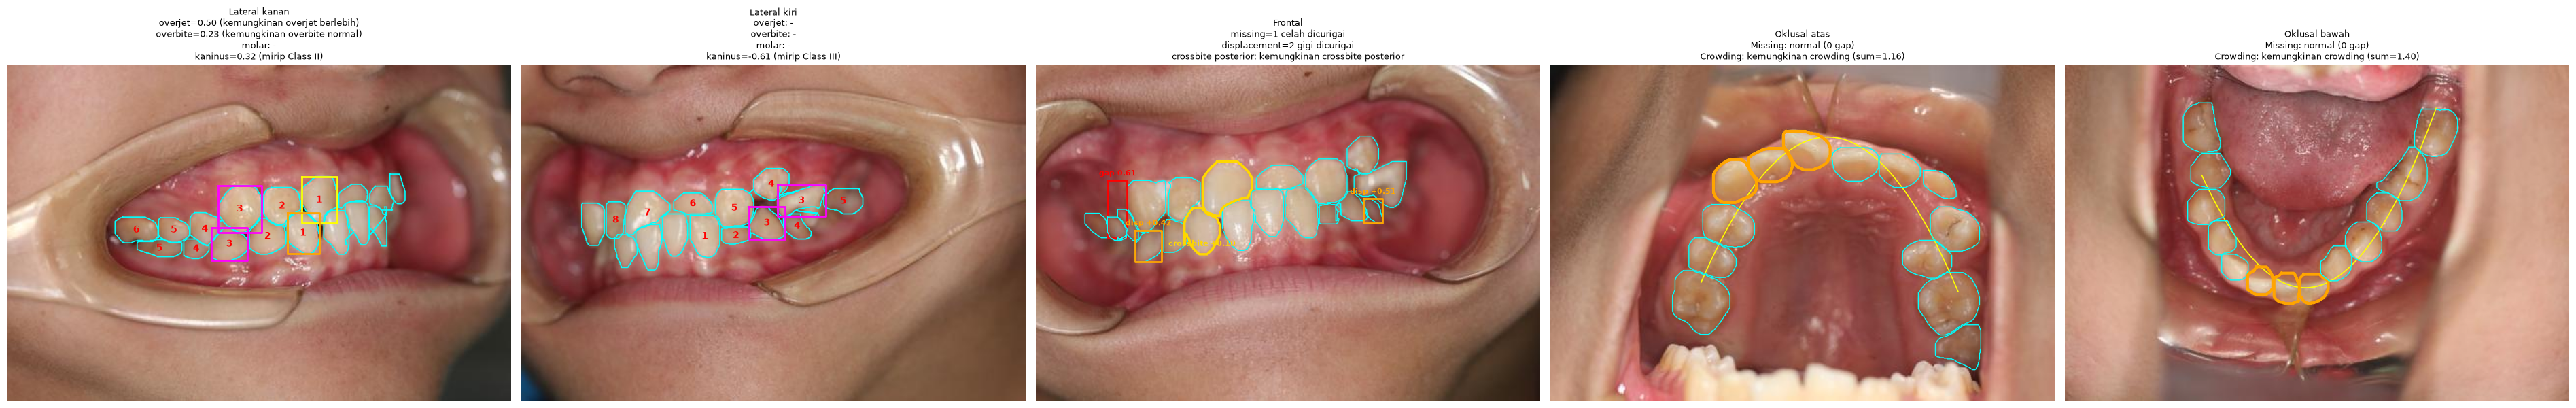

In [28]:
def plot_lateral(ax, r, label):
    ax.imshow(r["image"])
    for arch_result in (r["upper_result"], r["lower_result"]):
        for f, pos in arch_result:
            poly = f["points"]
            ax.plot(np.append(poly[:, 0], poly[0, 0]), np.append(poly[:, 1], poly[0, 1]), color="cyan", linewidth=1.2)
            if pos is not None:
                cx, cy = f["centroid"]
                ax.text(cx, cy, str(pos), color="red", fontsize=10, ha="center", va="center", fontweight="bold")
    if "incisors" in r:
        for key, color in [("upper_incisor", "yellow"), ("lower_incisor", "orange")]:
            x0, y0, x1, y1 = r["incisors"][key]["bbox"]
            ax.plot([x0, x1, x1, x0, x0], [y0, y0, y1, y1, y0], color=color, linewidth=2)
    if "molars" in r:
        for key in ("upper_molar", "lower_molar"):
            x0, y0, x1, y1 = r["molars"][key]["bbox"]
            ax.plot([x0, x1, x1, x0, x0], [y0, y0, y1, y1, y0], color="lime", linewidth=2)
    if "canines" in r:
        for key in ("upper_canine", "lower_canine"):
            x0, y0, x1, y1 = r["canines"][key]["bbox"]
            ax.plot([x0, x1, x1, x0, x0], [y0, y0, y1, y1, y0], color="magenta", linewidth=2)

    title = [label]
    title.append(f"overjet={r['overjet_proxy']:.2f} ({r['overjet_label']})" if "overjet_proxy" in r else "overjet: -")
    title.append(f"overbite={r['overbite_proxy']:.2f} ({r['overbite_label']})" if "overbite_proxy" in r else "overbite: -")
    title.append(f"molar={r['molar_ratio']:.2f} ({r['molar_label']})" if "molar_ratio" in r else "molar: -")
    title.append(f"kaninus={r['canine_ratio']:.2f} ({r['canine_label']})" if "canine_ratio" in r else "kaninus: -")
    for w in r.get("warnings", []):
        title.append(f"[!] {w}")
    ax.set_title("\n".join(title), fontsize=9, color=("red" if r.get("warnings") else "black"))
    ax.axis("off")


def plot_frontal(ax, r, crossbite):
    ax.imshow(r["image"])
    for arch_name in ("upper", "lower"):
        for f in r[arch_name]:
            poly = f["points"]
            ax.plot(np.append(poly[:, 0], poly[0, 0]), np.append(poly[:, 1], poly[0, 1]), color="cyan", linewidth=1)
        for f, ratio in r["disp"][arch_name]:
            x0, y0, x1, y1 = f["bbox"]
            ax.plot([x0, x1, x1, x0, x0], [y0, y0, y1, y1, y0], color="orange", linewidth=2)
            ax.text(f["centroid"][0], y0 - 5, f"disp {ratio:+.2f}", color="orange", fontsize=8, ha="center", fontweight="bold")
        for a, b, ratio in r["gaps"][arch_name]:
            gx0, gx1 = a["bbox"][2], b["bbox"][0]
            gy0 = min(a["bbox"][1], b["bbox"][1])
            gy1 = max(a["bbox"][3], b["bbox"][3])
            ax.plot([gx0, gx1, gx1, gx0, gx0], [gy0, gy0, gy1, gy1, gy0], color="red", linewidth=2)
            ax.text((gx0 + gx1) / 2, gy0 - 5, f"gap {ratio:.2f}", color="red", fontsize=8, ha="center", fontweight="bold")
    # Crossbite posterior (tepi bukal) -- gigi atas+bawah yg kena flag di-outline gold
    # tebal, beda warna dari gap (merah)/displacement (oranye) biar nggak ketuker.
    if crossbite is not None:
        for r_row in crossbite["flagged"]:
            for f in (r_row["f_upper"], r_row["f_lower"]):
                poly = f["points"]
                ax.plot(np.append(poly[:, 0], poly[0, 0]), np.append(poly[:, 1], poly[0, 1]), color="gold", linewidth=2.5)
            cx, cy = r_row["f_lower"]["centroid"]
            ax.text(cx, cy + 15, f"crossbite {r_row['ratio']:+.2f}", color="gold", fontsize=8, ha="center", fontweight="bold")
    n_gap = len(r["gaps"]["upper"]) + len(r["gaps"]["lower"])
    n_disp = len(r["disp"]["upper"]) + len(r["disp"]["lower"])
    crossbite_txt = crossbite["label"] if crossbite is not None else "tidak bisa dihitung"
    ax.set_title(f"Frontal\nmissing={n_gap} celah dicurigai\ndisplacement={n_disp} gigi dicurigai\ncrossbite posterior: {crossbite_txt}", fontsize=9)
    ax.axis("off")


def plot_oklusal(ax, r, label):
    """Missing (Arch Occupancy): sama persis gaya `14_occlusal_missing_crowding.ipynb`
    Section 12 -- kurva kuning, gap merah tebal + label rasio, gigi outlier (dibuang
    fit robust) magenta. Crowding (Little's Index): CUMA mask oranye tebal ke gigi yg
    kena titik kontak merah TANPA bintang (dalam jendela anterior tervalidasi) -- biar
    nggak terlalu rame, nggak ada garis/titik/angka tambahan kayak di notebook 14."""
    ax.imshow(r["image"])
    if r["missing"] is None:
        ax.set_title(f"{label}\n(cuma {len(r['feats'])} gigi kedetect, terlalu sedikit)", fontsize=9)
        ax.axis("off")
        return

    missing, crowding = r["missing"], r["crowding"]
    removed_ids = {id(f) for f in missing["removed"]}
    flagged_ids = crowding["flagged_tooth_ids"]

    ax.plot(missing["xs_curve"], missing["ys_curve"], color="yellow", linewidth=1.2)
    for f in r["feats"]:
        poly = f["points"]
        if id(f) in removed_ids:
            color, lw = "magenta", 1.5
        elif id(f) in flagged_ids:
            color, lw = "orange", 3
        else:
            color, lw = "cyan", 1
        ax.plot(np.append(poly[:, 0], poly[0, 0]), np.append(poly[:, 1], poly[0, 1]), color=color, linewidth=lw)
    for g in missing["gaps"]:
        i0, i1 = g["idx_range"]
        gx0, gy0 = missing["xs_curve"][i0], missing["ys_curve"][i0]
        gx1, gy1 = missing["xs_curve"][i1], missing["ys_curve"][i1]
        ax.plot([gx0, gx1], [gy0, gy1], color="red", linewidth=6, alpha=0.6)
        ax.text((gx0 + gx1) / 2, (gy0 + gy1) / 2 - 15, f"{g['length']/missing['avg_tooth_arc_width']:.2f}x", color="red", fontsize=9, fontweight="bold", ha="center")

    ax.set_title(f"{label}\nMissing: {missing['label']} ({len(missing['gaps'])} gap)\nCrowding: {crowding['label']} (sum={crowding['sum']:.2f})", fontsize=9)
    ax.axis("off")


fig, axes = plt.subplots(1, 5, figsize=(38, 8))
plot_lateral(axes[0], lat_kanan, "Lateral kanan")
plot_lateral(axes[1], lat_kiri, "Lateral kiri")
plot_frontal(axes[2], frontal, frontal_crossbite)
plot_oklusal(axes[3], oklusal_atas, "Oklusal atas")
plot_oklusal(axes[4], oklusal_bawah, "Oklusal bawah")
plt.tight_layout()

buf = io.BytesIO()
fig.savefig(buf, format="png", bbox_inches="tight")
plt.close(fig)
buf.seek(0)
display(IPImage(data=buf.read()))

## Section 9: Laporan akhir -- ringkasan angka & diagnosis

Overjet/Overbite/Angle: ambil yang **terburuk** dari kanan vs kiri (severity = seberapa jauh dari rentang normal). Missing & Crowding oklusal: gabungin gap/flag dari atas + bawah. Missing frontal vs oklusal: kalau jumlahnya BEDA, ditandai eksplisit -- oklusal (Arch Occupancy) lebih direkomendasikan (lihat `PROGRESS_SUMMARY.md`), tapi kalau beda jauh tetap perlu tinjau manual foto aslinya.

In [29]:
def severity(value, low, high):
    return max(low - value, 0, value - high)


print(f"=== LAPORAN AKHIR -- Pasien {PATIENT_ID} ===\n")

for name, low, high, key, lbl_key in [
    ("Overjet", OVERJET_LOW, OVERJET_HIGH, "overjet_proxy", "overjet_label"),
    ("Overbite", OVERBITE_LOW, OVERBITE_HIGH, "overbite_proxy", "overbite_label"),
]:
    candidates = []
    if key in lat_kanan:
        candidates.append(("kanan", lat_kanan[key], lat_kanan[lbl_key], lat_kanan.get("reliable", True), lat_kanan.get("warnings", [])))
    if key in lat_kiri:
        candidates.append(("kiri", lat_kiri[key], lat_kiri[lbl_key], lat_kiri.get("reliable", True), lat_kiri.get("warnings", [])))
    if not candidates:
        print(f"{name:10s}: tidak bisa dihitung (posisi gigi belum lengkap)")
        continue
    # sisi yang hasilnya ditandai bermasalah (lihat guard di Section 4) JANGAN dipilih
    # diam-diam sebagai "terburuk" -- kalau masih ada sisi yang bersih, pakai itu.
    # Kalau dua-duanya bermasalah, tetap dilaporkan tapi dengan peringatan eksplisit.
    reliable = [c for c in candidates if c[3]]
    pool = reliable if reliable else candidates
    worst = max(pool, key=lambda c: severity(c[1], low, high))
    note = "" if worst[3] else "  [!] TIDAK ANDAL -- " + "; ".join(worst[4])
    print(f"{name:10s}: {worst[1]:.2f} -- {worst[2]} (sisi {worst[0]}){note}")

# Angle -- reuse Section 10 `05_overjet_angle_from_mask.ipynb`: molar & kaninus
# dilaporkan TERPISAH (bukan digabung jadi 1 angka). Kalau dua-duanya lengkap tapi
# kesimpulannya beda, itu ditandai "perlu tinjau manual", bukan dipaksa pilih salah satu.
angle_candidates = [(side, r) for side, r in (("kanan", lat_kanan), ("kiri", lat_kiri))
                     if "molar_ratio" in r or "canine_ratio" in r]

if not angle_candidates:
    print(f"{'Angle':10s}: tidak bisa dihitung (posisi gigi belum lengkap)")
else:
    def angle_severity(r):
        # disagreement molar-vs-kaninus selalu diutamakan buat ditampilkan --
        # itu sinyal klinis yang lebih penting drpd besar-kecilnya deviasi individual.
        if r.get("molar_label") and r.get("canine_label") and r["molar_label"] != r["canine_label"]:
            return float("inf")
        vals = [v for v in (r.get("molar_ratio"), r.get("canine_ratio")) if v is not None]
        return max((severity(v, -ANGLE_THRESHOLD, ANGLE_THRESHOLD) for v in vals), default=0)

    side, r = max(angle_candidates, key=lambda c: angle_severity(c[1]))
    molar_txt = f"molar={r['molar_ratio']:.2f} ({r['molar_label']})" if "molar_ratio" in r else "molar: -"
    canine_txt = f"kaninus={r['canine_ratio']:.2f} ({r['canine_label']})" if "canine_ratio" in r else "kaninus: -"
    note = ""
    if "molar_label" in r and "canine_label" in r and r["molar_label"] != r["canine_label"]:
        note = " -- BEDA, perlu tinjau manual"
    print(f"{'Angle':10s}: {molar_txt}, {canine_txt} (sisi {side}){note}")

# Crossbite posterior (frontal, tepi bukal) -- Section 6, REKOMENDASI
if frontal_crossbite is None:
    print(f"{'Crossbite posterior':32s}: tidak bisa dihitung (posisi gigi belum lengkap)")
elif frontal_crossbite["flagged"]:
    detail = ", ".join(f"{r['side']} pos{r['posisi']}={r['ratio']:+.2f}" for r in frontal_crossbite["flagged"])
    print(f"{'Crossbite posterior':32s}: {frontal_crossbite['label']} ({detail})")
else:
    print(f"{'Crossbite posterior':32s}: {frontal_crossbite['label']}")

n_gap = len(frontal["gaps"]["upper"]) + len(frontal["gaps"]["lower"])
n_disp = len(frontal["disp"]["upper"]) + len(frontal["disp"]["lower"])
print(f"{'Displacement':32s}: {n_disp} gigi dicurigai")

# Missing (oklusal, Arch Occupancy) & Crowding (Little's Index) -- REKOMENDASI UTAMA,
# reuse `14_occlusal_missing_crowding.ipynb` Section 9 & 14. Gabungin hasil atas+bawah.
oklusal_views = [("atas", oklusal_atas), ("bawah", oklusal_bawah)]
n_gap_oklusal = sum(len(r["missing"]["gaps"]) for _, r in oklusal_views if r["missing"] is not None)

# Mekanisme reconciliation: Missing frontal (neighbor-gap, cross-check lama) vs Missing
# oklusal (Arch Occupancy, REKOMENDASI) dijalanin independen dari foto yg beda sudut --
# WAJAR kalau angkanya beda (bukan bug), tapi user harus tau kalau mereka nggak sepakat,
# bukan cuma ditampilin diam-diam berdampingan. Oklusal diprioritaskan (lebih tervalidasi,
# lihat PROGRESS_SUMMARY.md), tapi disagreement besar tetap ditandai perlu tinjau manual.
if n_gap != n_gap_oklusal:
    note = " -- BEDA, oklusal (Arch Occupancy) lebih direkomendasikan, tapi kalau beda jauh tetap tinjau manual foto aslinya"
else:
    note = ""
print(f"{'Missing (frontal, cross-check)':32s}: {n_gap} celah dicurigai")
print(f"{'Missing (oklusal, REKOMENDASI)':32s}: {n_gap_oklusal} celah dicurigai{note}")

crowding_flagged_views = [view for view, r in oklusal_views if r["crowding"] is not None and r["crowding"]["label"] == "kemungkinan crowding"]
if crowding_flagged_views:
    detail = ", ".join(f"{view} (sum={dict(oklusal_views)[view]['crowding']['sum']:.2f})" for view in crowding_flagged_views)
    print(f"{'Crowding (oklusal, REKOMENDASI)':32s}: kemungkinan crowding -- {detail}")
else:
    print(f"{'Crowding (oklusal, REKOMENDASI)':32s}: normal")

=== LAPORAN AKHIR -- Pasien 2018.08 ===

Overjet   : 0.50 -- kemungkinan overjet berlebih (sisi kanan)
Overbite  : 0.23 -- kemungkinan overbite normal (sisi kanan)
Angle     : molar: -, kaninus=-0.61 (mirip Class III) (sisi kiri)
Crossbite posterior             : kemungkinan crossbite posterior (kiri pos1=+0.10)
Displacement                    : 2 gigi dicurigai
Missing (frontal, cross-check)  : 1 celah dicurigai
Missing (oklusal, REKOMENDASI)  : 0 celah dicurigai -- BEDA, oklusal (Arch Occupancy) lebih direkomendasikan, tapi kalau beda jauh tetap tinjau manual foto aslinya
Crowding (oklusal, REKOMENDASI) : kemungkinan crowding -- atas (sum=1.16), bawah (sum=1.40)
